In [1]:
#activate venv: 
import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 33 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = ['minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'assists', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles',
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > current_gw
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 32.62 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155525 entries, 0 to 155524
Columns: 454 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(449), object(5)
memory usage: 538.7+ MB
None


In [4]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 311 potential features:
Total rows: 43375

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                           tackles_elo_p90sq_3      37361    86.13            6014
                               tackles_p90sq_3      37361    86.13            6014
                        recoveries_elo_p90sq_3      37361    86.13            6014
                            recoveries_p90sq_3      37361    86.13            6014
                    defensive_cont_elo_p90sq_3      37361    86.13            6014
                        defensive_cont_p90sq_3      37361    86.13            6014
                               cbi_elo_p90sq_3      37361    86.13            6014
                                   cbi_p90sq_3      37361    86.13            6014
                        recoveries_elo_p90sq_5      37305    86.01            6070
                            recoveries_p90sq_5      37305    86

In [5]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [6]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [7]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [8]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [9]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

In [10]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    # FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    # MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    # DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    # GK_mins_predictor.plot_results()

Cleaned df size: 2712/8052

Training Set Performance:
R² Score: 0.8267
RMSE: 13.6237
MAE: 11.2720

Test Set Performance:
R² Score: 0.4015
RMSE: 25.5682
MAE: 20.9602

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.309724
    opp_team_elo_p90sq_5    0.030178
    opp_team_elo_p90sq_3    0.026293
           minutes_elo_3    0.021136
        team_elo_p90sq_5    0.010283
       team_elo_p90sq_at    0.009141
opp_team_elo_elo_p90sq_5    0.009119
 opp_team_elo_elo_p90_10    0.008341
   goals_conceded_elo_10    0.008253
                elo_diff    0.008028
 goals_conceded_p90sq_at    0.007729
                 fixture    0.007447
        team_elo_p90sq_3    0.007348
            opp_team_elo    0.007254
          opp_team_elo_5    0.006922
   opp_team_elo_p90sq_at    0.006780
   clean_sheets_p90sq_at    0.006405
            bps_p90sq_at    0.006164
         opp_team_elo_10    0.006025
       team_elo_p90sq_10    0.006005
Cleaned df size: 9362/29977



In [11]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    # FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    # MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    # DEF_xG_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2800/4634

Training Set Performance:
R² Score: 0.5930
RMSE: 0.2509
MAE: 0.2000

Test Set Performance:
R² Score: 0.0650
RMSE: 0.3558
MAE: 0.2761

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.050904
                  fixture    0.038247
    goals_scored_p90sq_at    0.034604
          xg_over_g_ratio    0.029685
           bonus_p90sq_at    0.018462
             opp_team_elo    0.017875
           opp_team_elo_5    0.014888
           opp_team_elo_3    0.014530
          opp_team_elo_10    0.014116
         assists_p90sq_at    0.013213
         team_elo_p90sq_5    0.013202
         team_elo_p90sq_3    0.012389
total_points_elo_p90sq_10    0.010764
  goals_conceded_p90sq_at    0.010164
            minutes_elo_3    0.009981
                 team_elo    0.009491
        team_elo_p90sq_at    0.009102
               assists_at    0.008969
        team_elo_p90sq_10    0.008851
    

In [12]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    # FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    # MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    # DEF_xA_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 3005/4936

Training Set Performance:
R² Score: 0.6456
RMSE: 0.0709
MAE: 0.0486

Test Set Performance:
R² Score: 0.0626
RMSE: 0.1170
MAE: 0.0669

Top 20 Feature Importances:
              feature  importance
              assists    0.124239
              fixture    0.043174
         opp_team_elo    0.035571
       assists_elo_10    0.035096
       opp_team_elo_3    0.019307
 goals_conceded_elo_3    0.019253
     bps_elo_p90sq_10    0.011534
goals_conceded_elo_10    0.011418
 total_points_p90sq_3    0.011115
             elo_diff    0.010883
        minutes_elo_3    0.010762
   total_points_p90_3    0.010326
       opp_team_elo_5    0.009663
      xg_over_g_ratio    0.009177
   assists_elo_p90_10    0.008961
  total_points_p90_10    0.008948
 opp_team_elo_p90sq_3    0.008225
      opp_team_elo_10    0.007890
            assists_3    0.007700
 assists_elo_p90sq_10    0.007517
target=expected_assists_per90, MID_xA_predictor


In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    # FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    # MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    # DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    # GK_xGC_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 3005/4936

Training Set Performance:
R² Score: 0.7017
RMSE: 0.5050
MAE: 0.4093

Test Set Performance:
R² Score: 0.1982
RMSE: 0.8075
MAE: 0.6199

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.170361
                fixture    0.052723
           opp_team_elo    0.038452
        xg_over_g_ratio    0.037946
        opp_team_elo_10    0.018691
         opp_team_elo_5    0.016813
         opp_team_elo_3    0.012068
         assists_p90_at    0.011711
goals_conceded_p90sq_at    0.010951
  clean_sheets_p90sq_at    0.010767
  total_points_p90sq_at    0.009303
     minutes_elo_p90_10    0.009228
         bonus_p90sq_at    0.008626
  goals_scored_p90sq_at    0.008555
             assists_at    0.008298
  goals_conceded_elo_10    0.007826
       assists_p90sq_at    0.007758
             minutes_10    0.007707
      team_elo_p90sq_at    0.007568
    total_points_p90_10    0.00735

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    # FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    # MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    # DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    # GK_bps_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4417/4936

Training Set Performance:
R² Score: 0.5080
RMSE: 13.0673
MAE: 10.4442

Test Set Performance:
R² Score: 0.0619
RMSE: 17.0746
MAE: 12.9865

Top 20 Feature Importances:
                  feature  importance
                  assists    0.171660
                 elo_diff    0.040586
             opp_team_elo    0.027046
          opp_team_elo_10    0.021466
           opp_team_elo_3    0.013948
           opp_team_elo_5    0.013546
     minutes_elo_p90sq_10    0.012530
  goals_conceded_p90sq_at    0.011666
                  fixture    0.011664
      minutes_elo_p90sq_3    0.011405
clean_sheets_elo_p90sq_10    0.010759
         assists_p90sq_at    0.010731
           bonus_p90sq_at    0.009597
               bps_elo_10    0.009483
       opp_team_elo_elo_5    0.009219
                bps_elo_3    0.008987
              team_elo_10    0.008511
        goals_conceded_10    0.008050
            minutes_elo_3    0.008040
      minu

In [15]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    # GK_saves_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 4138/4412

Training Set Performance:
R² Score: 0.5476
RMSE: 1.3043
MAE: 1.0558

Test Set Performance:
R² Score: 0.0703
RMSE: 1.9149
MAE: 1.4965

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.130279
           opp_team_elo    0.019735
  opp_team_elo_p90sq_at    0.019422
         saves_p90sq_10    0.017120
                fixture    0.017007
           bps_p90sq_at    0.015829
         saves_p90sq_at    0.015391
     saves_elo_p90sq_10    0.015011
         opp_team_elo_5    0.014255
        opp_team_elo_10    0.014214
      team_elo_p90sq_at    0.013950
         opp_team_elo_3    0.013363
goals_conceded_p90sq_at    0.013216
  total_points_p90sq_at    0.012923
  clean_sheets_p90sq_at    0.012711
          saves_p90sq_5    0.011187
      saves_elo_p90sq_5    0.010467
   opp_team_elo_p90sq_3    0.010114
           bps_p90sq_10    0.010052
        bps_elo_p90sq_5    0.009817


In [16]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    # FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    # MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    # DEF_defcon_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 724/5449

Training Set Performance:
R² Score: 0.7700
RMSE: 1.3985
MAE: 1.1090

Test Set Performance:
R² Score: 0.1714
RMSE: 2.5760
MAE: 2.1292

Top 20 Feature Importances:
                   feature  importance
     clean_sheets_p90sq_at    0.031148
                minutes_10    0.030147
            assists_p90_at    0.022470
   goals_conceded_p90sq_at    0.020483
              opp_team_elo    0.020157
            opp_team_elo_3    0.018456
            opp_team_elo_5    0.016808
           xg_over_g_ratio    0.015992
     goals_conceded_elo_10    0.014782
           opp_team_elo_10    0.014649
                   fixture    0.014291
    goals_conceded_p90sq_3    0.014106
          assists_p90sq_at    0.013343
      goals_conceded_elo_3    0.012798
                  elo_diff    0.012650
goals_conceded_elo_p90sq_3    0.012517
                  team_elo    0.012359
      opp_team_elo_p90sq_3    0.011593
   total_poi

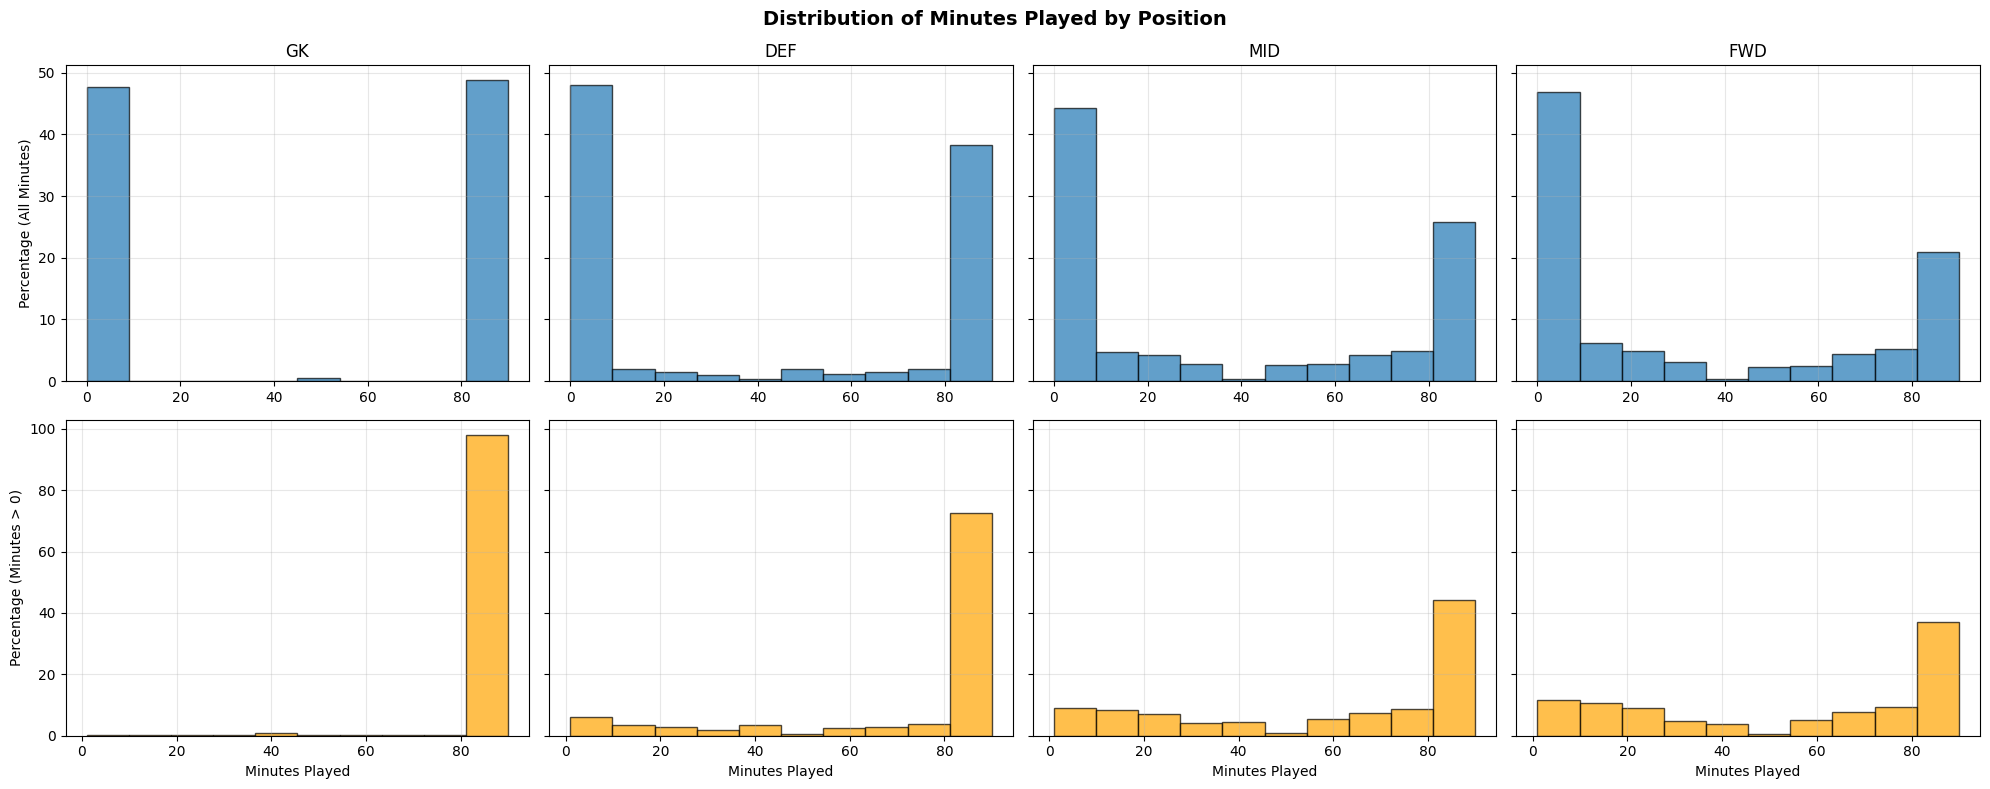

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.366


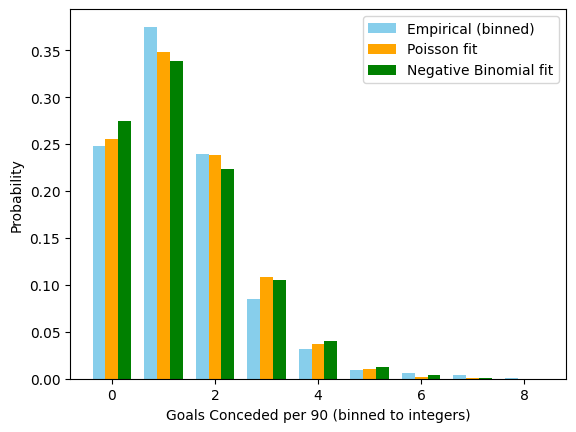

Mean: 1.356, Variance: 1.497
Overdispersion ratio (Var/Mean): 1.104
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.255


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.213


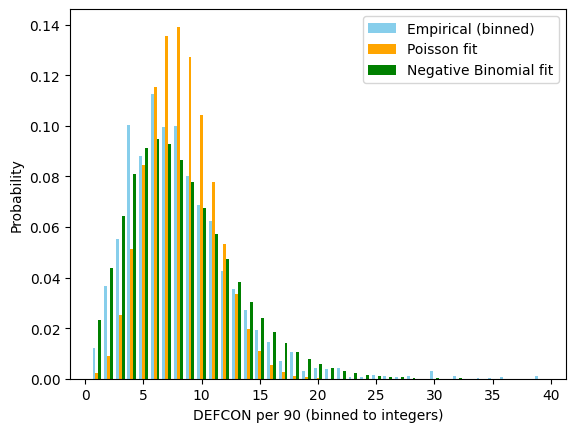

Mean: 8.205, Variance: 21.182
Overdispersion ratio (Var/Mean): 2.581
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [19]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.195


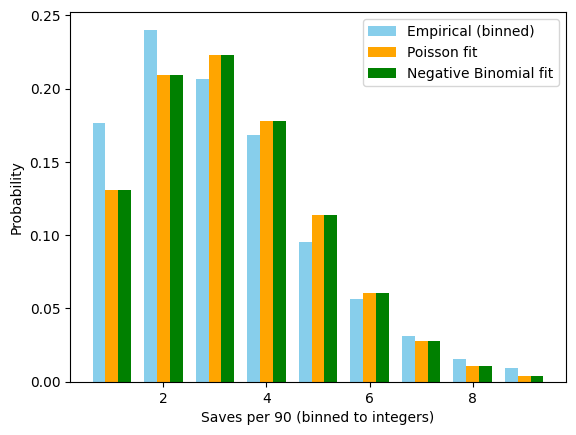

Mean: 3.195, Variance: 3.197
Overdispersion ratio (Var/Mean): 1.000
✅ Poisson assumption looks reasonable.


In [20]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [21]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [22]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [23]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16696\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    2470.000000
mean       59.295568
std        21.172874
min        12.456237
25%        39.755934
50%        60.451894
75%        79.838761
max        89.927298
Name: mins_pred, dtype: float64

In [24]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16696\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    2289.000000
mean        0.169760
std         0.135305
min         0.032206
25%         0.060244
50%         0.121899
75%         0.242556
max         0.765139
Name: xgp90_pred, dtype: float64

In [25]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16696\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    2289.000000
mean        0.088373
std         0.063960
min         0.022391
25%         0.043462
50%         0.073045
75%         0.112617
max         0.473000
Name: xap90_pred, dtype: float64

In [26]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16696\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    2470.000000
mean        1.579668
std         0.380311
min         0.424008
25%         1.353975
50%         1.530989
75%         1.767448
max         3.000066
Name: xgcp90_pred, dtype: float64

In [27]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16696\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    2470.000000
mean       14.304433
std         3.207017
min         5.019263
25%        12.167175
50%        13.842718
75%        16.486254
max        28.842767
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.447
Model:                            OLS   Adj. R-squared (uncentered):              0.447
Method:                 Least Squares   F-statistic:                          3.699e+04
Date:                Tue, 21 Apr 2026   Prob (F-statistic):                        0.00
Time:                        10:57:03   Log-Likelihood:                         -43157.
No. Observations:               45750   AIC:                                  8.632e+04
Df Residuals:                   45749   BIC:                                  8.632e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

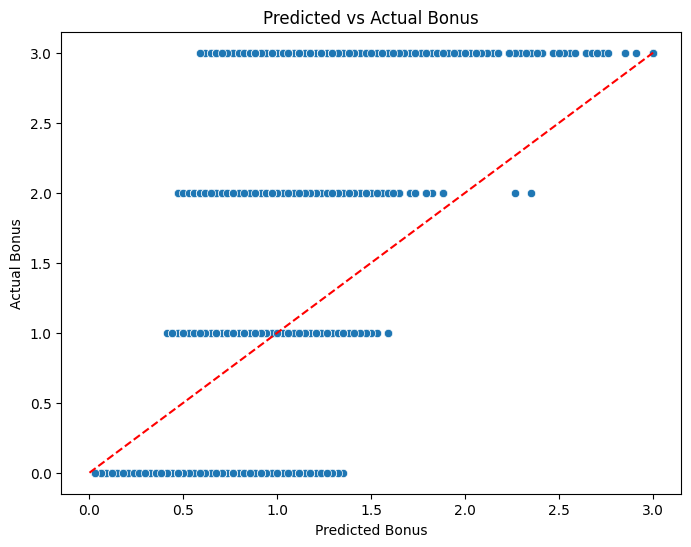

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459569  0.228249  1.107160  1.946142
FWD           0.331150  0.198305  1.047402  1.712125
GK            0.488483  0.244855  1.112896  2.008576
GKP                NaN       NaN       NaN       NaN
MID           0.397276  0.244562  1.050221  1.826811


C:\Users\Chris\AppData\Local\Temp\ipykernel_16696\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [28]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [29]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_16696\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [30]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16696\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    181.000000
mean       3.145996
std        0.573739
min        1.281642
25%        2.731127
50%        3.129745
75%        3.504473
max        4.959892
Name: xsavesp90_pred, dtype: float64

In [31]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16696\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    2289.000000
mean        7.835681
std         1.913522
min         2.517169
25%         6.516656
50%         7.970916
75%         9.294801
max        15.980265
Name: xdefconp90_pred, dtype: float64

In [32]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
135626,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,34.0,Liverpool,1166.251807,48.474161,0.084562,0.100253,1.634735
135628,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,35.0,Bournemouth,1092.690932,48.699846,0.083340,0.106946,1.493877
135630,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,36.0,Everton,1067.473132,48.699846,0.083825,0.105978,1.527664
135632,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,37.0,Brentford,1072.620018,48.699846,0.083825,0.107064,1.570722
135634,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,38.0,Arsenal,1233.633174,48.731514,0.079087,0.103601,1.876241


In [33]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
142735,Jonah Kusi-Asare,737.0,45.0,Fulham,FWD,20252026.0,34.0,Aston Villa,1136.729368,32.072599,0.635028,0.173709,1.817451
139201,Eddie Nketiah,284.0,54.0,Crystal Palace,FWD,20252026.0,34.0,Liverpool,1166.251807,38.647132,0.574670,0.168570,1.851476
154937,William Osula,500.0,54.0,Newcastle,FWD,20252026.0,34.0,Arsenal,1233.633174,46.960578,0.557721,0.064159,1.762402
147310,Lorenzo Lucca,805.0,54.0,Nott'm Forest,FWD,20252026.0,34.0,Sunderland,1040.325697,45.880712,0.552892,0.154095,1.386281
150638,Norberto Bercique Gomes Betuncal,311.0,50.0,Everton,FWD,20252026.0,34.0,West Ham,997.982644,66.553387,0.550973,0.079427,1.330417
138196,Callum Marshall,626.0,43.0,West Ham,FWD,20252026.0,34.0,Everton,1067.473132,39.596545,0.538952,0.162398,1.420866
138412,Dane Scarlett,599.0,43.0,Spurs,FWD,20252026.0,34.0,Wolves,928.800141,27.110258,0.532439,0.171157,1.300751
153124,Saša Kalajdžić,656.0,49.0,Wolves,FWD,20252026.0,34.0,Spurs,954.775745,40.091844,0.529693,0.155281,1.418257
150094,Niclas Füllkrug,625.0,56.0,West Ham,FWD,20252026.0,34.0,Everton,1067.473132,36.654365,0.510907,0.165532,1.528649
154969,Wilson Isidor,560.0,50.0,Sunderland,FWD,20252026.0,34.0,Nott'm Forest,1027.931832,20.944348,0.490685,0.152694,1.305733


In [34]:
# -----------------------------------------------------------------------
# Build per-player overperformance factors from ALL historical data in df
# -----------------------------------------------------------------------
# stat_pairs: (actual_column, expected_column, output_key)
#   'xg' key  → will be applied to xgp90_pred
#   'xa' key  → will be applied to xap90_pred

from FPLStatOverperformanceAnalyzer import (
    FPLStatOverperformanceAnalyzer,
    build_player_adjustments,
    apply_adjustments,
)

overperf_adjustments = build_player_adjustments(
    df,
    stat_pairs=[
        ('goals_scored',  'expected_goals',   'xg'),
        ('assists',       'expected_assists',  'xa')],
    taper_k_90s=15.0, # 15 90s needed for 50% credibility (50% observed & 50% prior(1))
    only_if_significant=True, # only adjust if p < 0.05
    min_xstat=2.0, # need ≥2 cumulative xG/xA to run test
)

print(f"Computed adjustments for {len(overperf_adjustments)} players")

# Apply factors to prediction_data
#   - Saves original columns as xgp90_pred_raw / xap90_pred_raw
#   - Adds xg_overperf_factor / xa_overperf_factor columns for audit
prediction_data = apply_adjustments(
    prediction_data,
    overperf_adjustments,
    col_map={
        'xg': 'xgp90_pred',
        'xa': 'xap90_pred',
    },
)

# Show the adjustment for the next gameweek's top players
print(f"\nNext GW{current_gw + 1} Top Players with Overperformance Factors:")
(
    prediction_data[prediction_data['event'] == current_gw + 1]
    [['player_name_id','position', 'xg_overperf_factor', 'xa_overperf_factor',
      'xgp90_pred_raw', 'xgp90_pred',
      'xap90_pred_raw', 'xap90_pred']].groupby('player_name_id').agg({'position': 'first', 'xg_overperf_factor': 'mean', 'xa_overperf_factor': 'mean',
                                                                      'xgp90_pred_raw': 'mean', 'xgp90_pred': 'mean', 'xap90_pred_raw': 'mean', 'xap90_pred': 'mean'})
    .sort_values('xg_overperf_factor', ascending=False)
    .head(30))

Computed adjustments for 2611 players

Next GW34 Top Players with Overperformance Factors:


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOverperformanceAnalyzer.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[f"{col}_raw"]             = prediction_data[col].copy()
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOverperformanceAnalyzer.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[col]                      = prediction_data[col] * factors
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOv

,position,xg_overperf_factor,xa_overperf_factor,xgp90_pred_raw,xgp90_pred,xap90_pred_raw,xap90_pred
player_name_id,,,,,,,
Mason Mount,MID,3.906486,5.301460,0.251916,0.984106,0.136309,0.722639
Michael Keane,DEF,2.911731,1.000000,0.058307,0.169775,0.036356,0.036356
Youri Tielemans,MID,2.733002,2.301812,0.102408,0.279881,0.131289,0.302203
Conor Gallagher,MID,2.506693,3.352141,0.122077,0.306010,0.076349,0.255934
Granit Xhaka,MID,2.319571,3.169132,0.085644,0.198657,0.073787,0.233842
Callum Hudson-Odoi,MID,2.189256,1.948382,0.157747,0.345349,0.092987,0.181174
Ryan Sessegnon,MID,2.106033,2.315256,0.120164,0.253070,0.059784,0.138415
Jadon Sancho,MID,2.095004,1.583747,0.141956,0.297398,0.105713,0.167422
Jack Grealish,MID,2.077578,2.326780,0.356836,0.741354,0.306794,0.713843


In [35]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [36]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [37]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_16696\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_16696\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykerne

In [38]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event','fixture',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xg_overperf_factor', 'xa_overperf_factor','xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus','xpoints']]
fixture_predictions = predictions.copy()  # keep per-fixture detail
# Existing per-fixture xpoints are computed above
# Now aggregate to gameweek level by summing across fixtures within each event

predictions_by_gw = predictions.groupby(
    ['player_name_id', 'element', 'team_name', 'position', 'season', 'event', 'value'],
    as_index=False,
    dropna=False
).agg(
    # descriptive
    team_name=('team_name', 'first'),
    team_elo=('team_elo', 'first'),
    opp_team_name=('opp_team_name', lambda x: '; '.join(x.dropna())), # concatenate opponent names for multiple fixtures
    opp_team_elo=('opp_team_elo', 'mean'),
    position=('position', 'first'),
    value=('value', 'first'),
    #count fixtures to identify DGWs
    fixture_count=('fixture', 'count'),
    #sum points components across fixtures
    mins_pred=('mins_pred', 'sum'),
    xpoints=('xpoints', 'sum'),
    xpoints_mins=('xpoints_mins', 'sum'),
    xpoints_goals=('xpoints_goals', 'sum'),
    xpoints_assists=('xpoints_assists', 'sum'),
    xg_overperf_factor=('xg_overperf_factor', 'mean'),
    xa_overperf_factor=('xa_overperf_factor', 'mean'),
    xpoints_clean_sheets=('xpoints_clean_sheets', 'sum'),
    xpoints_shots_saved=('xpoints_shots_saved', 'sum'),
    xpoints_goals_conceded=('xpoints_goals_conceded', 'sum'),
    xpoints_defcon=('xpoints_defcon', 'sum'),
    xpoints_bonus=('xpoints_bonus', 'sum'),
    # rates average across fixtures
    xgp90_pred=('xgp90_pred', 'mean'),
    xap90_pred=('xap90_pred', 'mean'),
    xgcp90_pred=('xgcp90_pred', 'mean'),
)

predictions_by_gw[predictions_by_gw['player_name_id'].isna()]

,player_name_id,element,season,event,team_name,team_elo,opp_team_name,opp_team_elo,position,value,...,xg_overperf_factor,xa_overperf_factor,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xgp90_pred,xap90_pred,xgcp90_pred


In [39]:
#use for fixture-level analysis
table_name = "predictions_by_fixture"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=fixture_predictions)
    # preds = db_creator.table_to_df(table_name=table_name)
    # print(preds.info())

In [40]:
#use to make transfer decisions at gameweek level
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions_by_gw)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2470 entries, 0 to 2469
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          2470 non-null   object 
 1   element                 2470 non-null   float64
 2   season                  2470 non-null   float64
 3   event                   2470 non-null   float64
 4   team_name               2470 non-null   object 
 5   team_elo                2470 non-null   float64
 6   opp_team_name           2470 non-null   object 
 7   opp_team_elo            2470 non-null   float64
 8   position                2470 non-null   object 
 9   value                   2470 non-null   float64
 10  fixture_count           2470 non-null   float64
 11  mins_pred               2470 non-null   float64
 12  xpoints                 2470 non-null   float64
 13  xpoints_mins            2470 non-null   float64
 14  xpoints_goals           2470 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [42]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

In [43]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, fixture_count, opp_team_name, opp_team_elo, xpoints, fixture_count
                            FROM predictions
                        WHERE season = 20252026 
                          AND event = 33
                          AND player_name_id = 'Cole Palmer'
                            """)
view

,player_name_id,team_name,team_elo,season,event,fixture_count,opp_team_name,opp_team_elo,xpoints,fixture_count


In [44]:
print(f"Gameweek {current_gw+1} Predictions")
predictions_by_gw[
    predictions_by_gw['event']==current_gw+1
].pivot_table(index=['player_name_id',"element",'event',"value","team_name","position"], values='xpoints', aggfunc='sum').reset_index().sort_values(by='xpoints', ascending=False).head(20)

Gameweek 34 Predictions


,player_name_id,element,event,value,team_name,position,xpoints
282,Ollie Watkins,64.0,34.0,85.0,Aston Villa,FWD,6.658193
32,Ben Davies,571.0,34.0,43.0,Spurs,DEF,6.389191
254,Mohamed Salah,381.0,34.0,140.0,Liverpool,MID,6.055103
81,Declan Rice,21.0,34.0,72.0,Arsenal,MID,5.905678
46,Bukayo Saka,16.0,34.0,98.0,Arsenal,MID,5.658048
163,Jarrod Bowen,624.0,34.0,76.0,West Ham,FWD,5.611915
149,Jack Grealish,419.0,34.0,63.0,Everton,MID,5.605433
236,Mathias Jensen,126.0,34.0,49.0,Brentford,MID,5.134781
63,Conor Bradley,375.0,34.0,49.0,Liverpool,DEF,5.127439
133,Harvey Barnes,487.0,34.0,61.0,Newcastle,MID,5.071403


In [45]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (predictions_by_gw['event']>=current_gw)&(predictions_by_gw['event']<=current_gw+5)
predictions_by_gw[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW34 - GW38


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
401,Ollie Watkins,422.617535,9.603423,14.555077,6.345720,0.000000,0.0,0.000000,1.353287,2.749549,34.607056
48,Ben Davies,277.595424,6.950515,5.570583,14.235191,3.613095,0.0,-3.132250,2.698553,1.288467,31.224153
109,Declan Rice,426.434103,9.630250,8.224586,5.106829,2.231931,0.0,0.000000,2.560701,2.669972,30.424269
365,Mohamed Salah,362.767949,8.891061,11.040574,4.208365,1.151616,0.0,0.000000,2.560701,2.125215,29.977532
68,Bukayo Saka,331.783672,8.268247,9.537787,3.950769,2.155937,0.0,0.000000,2.560701,2.488708,28.962149
227,Jarrod Bowen,422.139407,9.599758,9.442968,5.608312,0.000000,0.0,0.000000,1.353287,2.120631,28.124955
201,Jack Grealish,244.350314,6.237094,10.102138,5.570011,0.475611,0.0,0.000000,2.560701,2.532066,27.477622
182,Harvey Barnes,309.012294,7.724655,10.899214,3.251849,0.948517,0.0,0.000000,2.560701,1.806723,27.191660
165,Gabriel dos Santos Magalhães,418.977734,9.576019,2.593728,1.577505,8.245883,0.0,-1.287437,2.698553,2.849556,26.253806
340,Mathias Jensen,425.286069,9.622297,7.631776,2.556713,1.098425,0.0,0.000000,2.560701,2.333237,25.803150


In [46]:
print("Rest of Season Predictions")
predictions_by_gw.groupby('player_name_id')[['team_name','opp_team_elo','mins_pred',
                                           'xpoints', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus'
                                           ]].agg({'team_name':'first','opp_team_elo':'mean','mins_pred':'mean','xpoints':'sum', 'xpoints_mins':'sum', 'xpoints_goals':'sum',
                                           'xpoints_assists':'sum', 'xpoints_clean_sheets':'sum',
                                           'xpoints_shots_saved':'sum','xpoints_goals_conceded':'sum','xpoints_defcon':'sum','xpoints_bonus':'sum'}
                                                  ).reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,team_name,opp_team_elo,mins_pred,xpoints,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus
401,Ollie Watkins,Aston Villa,1056.356074,84.523507,34.607056,9.603423,14.555077,6.345720,0.000000,0.0,0.000000,1.353287,2.749549
48,Ben Davies,Spurs,1046.991181,55.519085,31.224153,6.950515,5.570583,14.235191,3.613095,0.0,-3.132250,2.698553,1.288467
109,Declan Rice,Arsenal,1005.929379,85.286821,30.424269,9.630250,8.224586,5.106829,2.231931,0.0,0.000000,2.560701,2.669972
365,Mohamed Salah,Liverpool,1094.130182,72.553590,29.977532,8.891061,11.040574,4.208365,1.151616,0.0,0.000000,2.560701,2.125215
68,Bukayo Saka,Arsenal,1005.929379,66.356734,28.962149,8.268247,9.537787,3.950769,2.155937,0.0,0.000000,2.560701,2.488708
227,Jarrod Bowen,West Ham,1087.541289,84.427881,28.124955,9.599758,9.442968,5.608312,0.000000,0.0,0.000000,1.353287,2.120631
201,Jack Grealish,Everton,1058.736084,48.870063,27.477622,6.237094,10.102138,5.570011,0.475611,0.0,0.000000,2.560701,2.532066
182,Harvey Barnes,Newcastle,1079.079010,61.802459,27.191660,7.724655,10.899214,3.251849,0.948517,0.0,0.000000,2.560701,1.806723
165,Gabriel dos Santos Magalhães,Arsenal,1005.929379,83.795547,26.253806,9.576019,2.593728,1.577505,8.245883,0.0,-1.287437,2.698553,2.849556
340,Mathias Jensen,Brentford,1114.697487,85.057214,25.803150,9.622297,7.631776,2.556713,1.098425,0.0,0.000000,2.560701,2.333237


In [47]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [48]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [49]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            SUM(pg.total_points) AS total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    GROUP BY p.player_name_id, p.element, p.season, p.event,
             p.team_name, p.team_elo, p.position, p.value, p.in_any_team, p.in_my_team,
             p.opp_team_name, p.opp_team_elo, p.fixture_count,
             p.xpoints, p.xpoints_mins, p.xpoints_goals, p.xpoints_assists, p.xg_overperf_factor,p.xa_overperf_factor,
             p.xpoints_clean_sheets, p.xpoints_shots_saved, p.xpoints_goals_conceded,
             p.xpoints_defcon, p.xpoints_bonus,
             p.mins_pred, p.xgp90_pred, p.xap90_pred, p.xgcp90_pred,
             p.prediction_timestamp, p.prediction_gameweek
    Limit 0 -- no data yet, just create the table structure;
""")

In [50]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 2470 new predictions to predictions_allgws


In [51]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','season','event','fixture','total_points']][future_filter].head()

,player_name_id,season,event,fixture,total_points


In [52]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=25)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].sort_values(by='event').head(10)

,player_name_id,event,season,total_points,minutes
192297,Erling Haaland,25.0,20252026.0,11.0,90.0
192298,Erling Haaland,26.0,20252026.0,5.0,45.0
192299,Erling Haaland,27.0,20252026.0,6.0,90.0
192300,Erling Haaland,28.0,20252026.0,0.0,0.0
192301,Erling Haaland,29.0,20252026.0,2.0,90.0
192302,Erling Haaland,30.0,20252026.0,2.0,90.0
192303,Erling Haaland,32.0,20252026.0,2.0,90.0
192304,Erling Haaland,33.0,20252026.0,6.0,90.0
192305,Erling Haaland,33.0,20252026.0,0.0,0.0
205859,Erling Haaland,35.0,20252026.0,NaN,NaN


In [53]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
19365,Erling Haaland,2026-01-27 11:00:04.422834,24.0,3.886675,NaN
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
...,...,...,...,...,...
26620,Erling Haaland,2026-02-01 11:57:12.353330,38.0,3.209951,NaN
19374,Erling Haaland,2026-01-27 11:00:04.422834,38.0,3.494566,NaN
13478,Erling Haaland,2026-01-05 18:33:33.065519,38.0,4.510429,NaN
122871,Erling Haaland,2026-04-11 19:52:12.859110,38.0,4.091495,NaN


In [54]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 33.0   3.403198
                                                          34.0   3.418776
                                                          35.0   3.388855
                                                          36.0   3.436291
                                                          37.0   3.421387
...                                                                   ...
2026-04-21 10:57:13.932011 33                  20252026.0 34.0   3.387258
                                                          35.0   3.406870
                                                          36.0   3.379885
                                                          37.0   3.372130
                                                          38.0   3.336354

[197 rows x 1 columns]

In [55]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [56]:
filtered = (df_complete['player_name_id'] == 'Erling Haaland')&(
    df_complete['season']==20252026) & (df_complete['event']==current_gw+1)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points
13474,2026-01-05 18:33:33.065519,20,20252026.0,34.0,7.434340,NaN
5669,2026-01-26 14:27:00.627006,23,20252026.0,34.0,4.581043,NaN
19371,2026-01-27 11:00:04.422834,23,20252026.0,34.0,4.330928,NaN
26617,2026-02-01 11:57:12.353330,24,20252026.0,34.0,4.122204,NaN
33634,2026-02-02 13:38:00.840050,24,20252026.0,34.0,4.597716,NaN
40651,2026-02-03 14:41:19.430154,24,20252026.0,34.0,4.690749,NaN
47465,2026-02-09 12:29:03.939012,25,20252026.0,34.0,5.309112,NaN
53799,2026-02-13 13:00:38.658664,26,20252026.0,34.0,5.109187,NaN
59829,2026-02-19 17:56:20.307174,26,20252026.0,34.0,5.062808,NaN
65860,2026-02-20 10:52:25.776847,26,20252026.0,34.0,5.132989,NaN


In [57]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,35.500000
min,2026-01-07 16:29:20.849190,33.000000
25%,2026-01-07 16:29:20.849189888,34.000000
50%,2026-01-08 04:37:05.395073024,35.500000
75%,2026-01-08 16:44:49.940955904,37.000000
max,2026-01-08 16:44:49.940956,38.000000
std,NaN,1.744557


In [58]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [59]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 33.17 minute(s)

Finished in 39.23 minute(s)


In [60]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)